# LLM Evaluation on Bug Triage

Walkthrough notebook for all 8 pipeline steps.

**Three questions answered:**
1. What themes do bugs repeatedly report? (unsupervised clustering)
2. Can a new bug automatically find its duplicate? (semantic dedup, hit@k / MRR)
3. Are LLM-extracted fields trustworthy? (self-correcting agent + LLM-as-judge, Cohen kappa)

Set `OPENAI_API_KEY` in `.env` before running steps 2-6.

In [2]:
import os, sys
os.environ.setdefault('MPLCONFIGDIR', '/tmp/mpl')
import matplotlib.pyplot as plt
%matplotlib inline

# Auto-reload pipeline.py on every cell run, so edits to the module take
# effect without restarting the kernel.
%load_ext autoreload
%autoreload 2

import pipeline
from pipeline import (
    step1_load, step2_embed, step3_cluster, step4_topic_stats,
    step5_extract, step6_kappa, step7_dedup, step8_readout,
)

# Set SAMPLE=True for a quick smoke-test (fewer bugs, lower API cost)
SAMPLE = False
print('setup ok')

setup ok


## Step 1 - Load corpus

`bugs.csv`: one row per bug (id, component, severity, summary, description, role).

`dup_pairs.csv`: 4,987 hard-label pairs (dup_id, master_id) used for dedup evaluation in Step 7.

In [4]:
bugs, pairs = step1_load()

if SAMPLE:
    bugs  = bugs.sample(2000, random_state=42).reset_index(drop=True)
    pairs = pairs[pairs['dup_id'].isin(bugs['id']) &
                  pairs['master_id'].isin(bugs['id'])]

bugs[['id', 'component', 'role', 'summary']].head(3)

[load] bugs=13,019  dup_pairs=4,987  masters=3,549
[load] roles: {'dup': 5000, 'corpus': 4745, 'master': 3274}
[load] description coverage: 93.3%  median desc words: 91


,id,component,role,summary
0,11040,Filters,master,"Allow filters to control biff UI (i.e. only notify me of ""important"" messages)"
1,12306,Backend,master,Message notes/annotations
2,18764,Networking,master,Full rfc2557 MHTML multipart/related support in BROWSER


## Step 2 - Embed into ChromaDB (cached)

Every bug text is embedded with `text-embedding-3-small` into a local ChromaDB.
Re-running costs nothing: already-embedded bugs are skipped automatically.

The same vector store is reused by the dedup retrieval (Step 7) and the agent tools (Step 5).

In [5]:
col = step2_embed(bugs)
print(f'ChromaDB collection size: {col.count():,}')

[embed] all 13,019 bugs already cached in ChromaDB — skipping
ChromaDB collection size: 13,019


## Step 3 - Cluster topics

KMeans is fit on all embeddings. Optimal k is selected by silhouette score on a 3,000-bug
sample. Each cluster is named by GPT-4o from 10 representative summaries.

Note: silhouette is low because duplicate bugs embed close to their master
(the retrieval signal), blurring global cluster geometry. Low silhouette != no
semantic structure: duplicate pairs still land in the same cluster at many times
the random baseline rate.

In [6]:
bugs = step3_cluster(bugs, col)
bugs['cluster_theme'].value_counts().head(12)

[cluster]   k= 8  silhouette=0.026
[cluster]   k=10  silhouette=0.028
[cluster]   k=12  silhouette=0.025
[cluster]   k=14  silhouette=0.031
[cluster]   k=16  silhouette=0.032
[cluster]   k=18  silhouette=0.033
[cluster]   k=20  silhouette=0.033
[cluster]   k=22  silhouette=0.025
[cluster]   k=24  silhouette=0.026
[cluster] best k=18  silhouette=0.0335
[cluster] themes: ['JavaScript Engine Optimization and Bugs', 'IP Protection Feature Bugs', 'UI/UX Interaction and Functionality Issues', 'Mozilla Bug Cluster: Display, Security, and Functionality Issues', 'Intermittent and Frequent Test Failures', 'Gemini Chat Sidebar Issues', 'Frequent PDF.js and Opus Updates', 'WebKit Export Sync Issues', 'Mozilla Crash and Memory Issues', 'Security and Compatibility Enhancements Needed', 'Enhanced Messaging and Address Management', 'New Tab Features and Bugs', 'Web Platform Test Failures Cluster', 'Email Client Functionality and Formatting Issues', 'SVG and CSS Rendering Issues', 'Browser Tab and Sess

cluster_theme
Mozilla Bug Cluster: Display, Security, and Functionality Issues    1266
Security and Compatibility Enhancements Needed                      1098
Firefox Display and Functionality Issues                             981
Intermittent and Frequent Test Failures                              968
Web Platform Test Failures Cluster                                   957
Email Client Functionality and Formatting Issues                     917
SVG and CSS Rendering Issues                                         869
Enhanced Messaging and Address Management                            835
Mozilla Crash and Memory Issues                                      806
UI/UX Interaction and Functionality Issues                           743
JavaScript Engine Optimization and Bugs                              715
Browser Tab and Session Management Issues                            688
Name: count, dtype: int64

### Cluster quality: duplicate same-cluster rate vs. random baseline

In [7]:
import numpy as np

id2cluster = dict(zip(bugs['id'].astype(str), bugs['cluster_theme'].fillna('')))
valid_pairs = [(str(d), str(m)) for d, m in
               zip(pairs['dup_id'], pairs['master_id'])
               if str(d) in id2cluster and str(m) in id2cluster]

sc = sum(id2cluster[d] == id2cluster[m] for d, m in valid_pairs)
us = len(valid_pairs)

themes = bugs['cluster_theme'].dropna().tolist()
unique_themes = list(bugs['cluster_theme'].dropna().unique())
counts = np.array([themes.count(t) for t in unique_themes], dtype=float)
frac = counts / counts.sum()
rand_same = float((frac ** 2).sum())

print(f'Usable dup pairs : {us:,}')
print(f'Same-cluster rate: {sc/us:.1%}  (random baseline {rand_same:.1%},  lift x{sc/us/rand_same:.0f})')

Usable dup pairs : 4,987
Same-cluster rate: 71.9%  (random baseline 6.5%,  lift x11)


## Step 4 - Topic prevalence with Wilson confidence intervals

Reporting a topic share without uncertainty is statistically incomplete.
Wilson CIs are more accurate than the normal approximation near 0 and 1
and are guaranteed to stay inside [0, 1].

In [8]:
topic_df = step4_topic_stats(bugs)
topic_df.head(3)

[topic_stats] N=13,019  95% Wilson CI:
  Mozilla Bug Cluster: Display, Secu  9.72%  [9.23%, 10.25%]  (n=1266)
  Security and Compatibility Enhance  8.43%  [7.97%, 8.92%]  (n=1098)
  Firefox Display and Functionality   7.54%  [7.09%, 8.00%]  (n=981)
  Intermittent and Frequent Test Fai  7.44%  [7.00%, 7.90%]  (n=968)
  Web Platform Test Failures Cluster  7.35%  [6.91%, 7.81%]  (n=957)
  Email Client Functionality and For  7.04%  [6.62%, 7.50%]  (n=917)
  SVG and CSS Rendering Issues        6.67%  [6.26%, 7.12%]  (n=869)
  Enhanced Messaging and Address Man  6.41%  [6.01%, 6.85%]  (n=835)
  Mozilla Crash and Memory Issues     6.19%  [5.79%, 6.62%]  (n=806)
  UI/UX Interaction and Functionalit  5.71%  [5.32%, 6.12%]  (n=743)
  JavaScript Engine Optimization and  5.49%  [5.11%, 5.90%]  (n=715)
  Browser Tab and Session Management  5.28%  [4.91%, 5.68%]  (n=688)
[topic_stats] saved topic_prevalence.png


,theme,count,share,ci_lo,ci_hi
0,"Mozilla Bug Cluster: Display, Security, and Functionality Issues",1266,0.097242,0.092271,0.102451
1,Security and Compatibility Enhancements Needed,1098,0.084338,0.079686,0.089235
2,Firefox Display and Functionality Issues,981,0.075351,0.070941,0.080012


## Step 5 - Extraction agent (LangGraph + MCP)

The agent extracts `{area, severity, kind}` for each bug in a 50-bug sample.

Graph layout:
```
                         START
                           │
                           ▼
              ┌──────► supervisor ──► FINISH ──► END
              │  （decides which to call）
              │            │ research / extract / critique / FINISH
              │   ┌────────┼───────────┐
              │   ▼        ▼           ▼
              │ researcher extractor  critic
              │ (ReAct) (JSON out)  (schema+faithfulness)
              │   │ ▲        │          │
              │   ▼ │        │          │
              │  tools       │          │
              └───┴──────────┴──────────┘
                （all workers return to supervisor）
```

- supervisor: only branching point; routes dynamically based on state
- researcher: multi-hop tool loop (search_similar_bugs / read_bug / component_prior)
- extractor: produces JSON from bug text + evidence
- critic: schema check then LLM-as-judge faithfulness check

MCP grounding: field catalog (definitions + enums) served by `mcp_server.py`.

Cost: ~300 OpenAI API calls for 50 bugs. Set SAMPLE=True to reduce to 10 bugs.

In [9]:
import pipeline
pipeline.EXTRACT_N = 10 if SAMPLE else 50

extract_df = step5_extract(bugs, col)
extract_df[['id', 'component', 'llm_area', 'llm_area_comp',
            'llm_severity', 'llm_kind', 'llm_dup_ids',
            '_steps', '_ok', '_traj']].head()

[mcp] catalog loaded: ['area', 'severity', 'kind']  |  taxonomy: 281 components
[agent] compiled: __start__ / supervisor / researcher / extractor / critic / __end__
[extract]   processed 15/50
  [rate limit] waiting 5s before retry 1/6 …
[extract]   processed 30/50
  [rate limit/researcher] waiting 5s …
  [rate limit] waiting 5s before retry 1/6 …
  [rate limit/researcher] waiting 5s …
  [rate limit] waiting 5s before retry 1/6 …
  [rate limit] waiting 5s before retry 1/6 …
  [rate limit] waiting 5s before retry 1/6 …
[extract]   processed 45/50
  [rate limit] waiting 5s before retry 1/6 …
[extract]   processed 50/50
[extract] valid yield: first-pass 52.0% -> after critique-retry 64.0% (self-correction +12.0%)
[extract] mean supervisor steps 6.7 | 2% solved with ZERO retrieval
[extract] dedup flagged 30/50 bugs (sim ≥ 0.75)


,id,component,llm_area,llm_area_comp,llm_severity,llm_kind,llm_dup_ids,_steps,_ok,_traj
0,764076,Layout: Scrolling and Overflow,Layout: Scrolling and Overflow,Layout: Scrolling and Overflow,med,ui,2027840,6,True,research → extract → critique → extract → critique → FINISH
1,354493,Networking,Networking,Networking,med,security,,4,True,research → extract → critique → FINISH
2,2022394,Storage: localStorage & sessionStorage,Storage,Storage,high,security,,4,True,research → extract → critique → FINISH
3,1983429,Mail Window Front End,Mail Window Front End,Mail Window Front End,med,ui,"2039936,1944442",4,True,research → extract → critique → FINISH
4,1918296,OS Integration,OS Integration,OS Integration,med,ui,1977643,4,True,research → extract → critique → FINISH


## Step 6 - Auto-rater x Cohen kappa

Cohen kappa between LLM extractions and human labels (human_labels.csv).
Kappa calibrates how much to trust the LLM-as-judge agreement rate.

The trajectory chart shows many different paths to FINISH -- evidence
this is a real agent, not a fixed workflow.

In [10]:
kappa_results = step6_kappa(extract_df)
print(kappa_results)

[kappa] saved agent_trajectories.png
[kappa] labeled rows: 50 total, 46 used for κ (4 held out as few-shot anchors)
[kappa] judge model: gpt-4o | threshold: 5
[kappa] Cohen's κ (judge vs human) = 0.502
confusion (rows=human, cols=judge):
 [[ 4  1]
 [ 5 36]]
judge good=37/46 (80%) | human good=41/46 (89%)
{'kappa': 0.5018050541516246, 'eval_df':          id                               component  \
0    764076          Layout: Scrolling and Overflow   
1    354493                              Networking   
2   2022394  Storage: localStorage & sessionStorage   
3   1983429                   Mail Window Front End   
4   1918296                          OS Integration   
5   2050964                         DOM: Navigation   
6   1998224                          Tabbed Browser   
7   2037402                             Settings UI   
8   2043898                  Layout: Text and Fonts   
9   2041280                             Address Bar   
10  1978660                             Address 

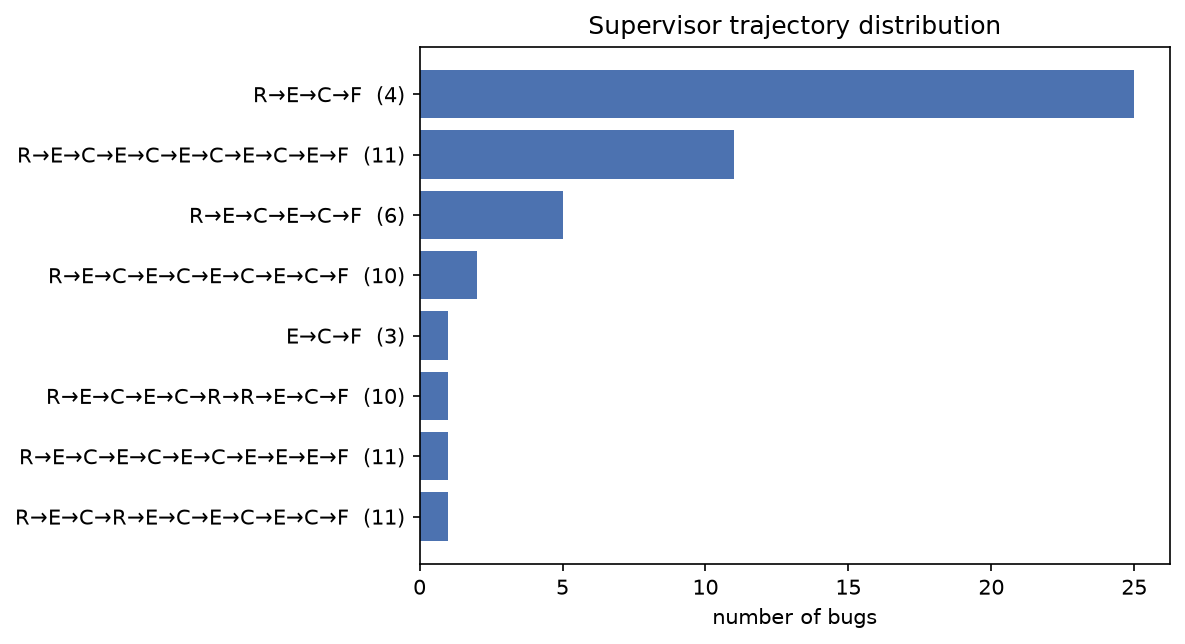

In [11]:
import os
from IPython.display import Image, display
if os.path.exists('agent_trajectories.png'):
    display(Image('agent_trajectories.png'))

## Step 7 - Dedup retrieval evaluation (hit@k / MRR)

For each of the 4,987 duplicate bugs, query ChromaDB for top-10 similar bugs
and check whether the correct master appears in the results.

- hit@k: fraction of queries where the master is in the top-k results
- MRR (Mean Reciprocal Rank): average of 1 / rank-of-correct-master

In [12]:
dedup_metrics = step7_dedup(bugs, pairs, col)
dedup_metrics

[dedup] evaluating 4,987/4,987 pairs (both dup and master embedded)
[dedup]   1,000/4,987
[dedup]   2,000/4,987
[dedup]   3,000/4,987
[dedup]   4,000/4,987
[dedup]   4,987/4,987
[dedup] hit@1=0.362  hit@5=0.594  hit@10=0.667  MRR=0.459


{'hit@1': 0.3619410467214758,
 'hit@5': 0.5939442550631642,
 'hit@10': 0.6665329857629838,
 'mrr': 0.4590451045734776}

## Step 8 - Final readout

In [13]:
step8_readout(topic_df, extract_df, kappa_results, dedup_metrics)


PIPELINE SUMMARY

-- Top 5 bug themes --
  Mozilla Bug Cluster: Display, Security,   9.7%
  Security and Compatibility Enhancements   8.4%
  Firefox Display and Functionality Issues  7.5%
  Intermittent and Frequent Test Failures   7.4%
  Web Platform Test Failures Cluster        7.4%

-- Extraction agent (LLM-as-judge) --
  first-pass yield:   52.0%
  final valid yield:  64.0%
  mean steps:         6.7
  Cohen's κ (judge vs human): 0.502

-- Dedup retrieval --
  hit@1: 0.362
  hit@5: 0.594
  hit@10: 0.667
  mrr: 0.459
